In [1]:
#this command might be relevant ony on GPU nodes. But the notebook will run on CPU as well
#If running on CPU remove the command wherever it appears
!nvidia-smi

Wed Nov 12 22:52:59 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   60C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!apt-get install default-jre
!java -version

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  at-spi2-core ca-certificates-java default-jre-headless fonts-dejavu-core
  fonts-dejavu-extra gsettings-desktop-schemas java-common libatk-bridge2.0-0
  libatk-wrapper-java libatk-wrapper-java-jni libatk1.0-0 libatk1.0-data
  libatspi2.0-0 libpcsclite1 libxcomposite1 libxtst6 libxxf86dga1
  openjdk-11-jre openjdk-11-jre-headless session-migration x11-utils
Suggested packages:
  pcscd libnss-mdns fonts-ipafont-gothic fonts-ipafont-mincho
  fonts-wqy-microhei | fonts-wqy-zenhei fonts-indic mesa-utils
The following NEW packages will be installed:
  at-spi2-core ca-certificates-java default-jre default-jre-headless
  fonts-dejavu-core fonts-dejavu-extra gsettings-desktop-schemas java-common
  libatk-bridge2.0-0 libatk-wrapper-java libatk-wrapper-java-jni libatk1.0-0
  libatk1.0-data libatspi2.0-0 libpcsclite1 libxcomposite1 libxtst6
  libxx

In [3]:
!pip install h2o

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.0/266.0 MB 4.6 MB/s eta 0:00:00


In [4]:
 import h2o

In [5]:
h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "11.0.28" 2025-07-15; OpenJDK Runtime Environment (build 11.0.28+6-post-Ubuntu-1ubuntu122.04.1); OpenJDK 64-Bit Server VM (build 11.0.28+6-post-Ubuntu-1ubuntu122.04.1, mixed mode, sharing)
  Starting server from /usr/local/lib/python3.12/dist-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmp6huo1478
  JVM stdout: /tmp/tmp6huo1478/h2o_unknownUser_started_from_python.out
  JVM stderr: /tmp/tmp6huo1478/h2o_unknownUser_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,02 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.8
H2O_cluster_version_age:,1 month and 4 days
H2O_cluster_name:,H2O_from_python_unknownUser_6n7bwz
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.168 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


In [6]:
from h2o.automl import H2OAutoML

In [7]:
## Imports

import pandas as pd
import numpy as np

df = pd.read_csv("athletes_clean.csv")

In [8]:
h2o_df = h2o.H2OFrame(df)

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


In [9]:
h2o_df.types

{'Unnamed: 0': 'int',
 'athlete_id': 'int',
 'region': 'enum',
 'gender': 'enum',
 'age': 'int',
 'height': 'int',
 'weight': 'int',
 'candj': 'int',
 'snatch': 'int',
 'deadlift': 'int',
 'backsq': 'int',
 'eat': 'enum',
 'background': 'enum',
 'experience': 'enum',
 'schedule': 'enum',
 'howlong': 'enum',
 'total lift': 'int'}

In [10]:
# Clean the data in H2O
columns_to_drop = ["Unnamed: 0", "athlete_id"]
for col in columns_to_drop:
    if col in h2o_df.columns:
        h2o_df = h2o_df.drop(col)

# Convert categorical columns to factors
categorical_columns = ['region', 'gender', 'eat', 'background', 'experience', 'schedule', 'howlong']
for col in categorical_columns:
    if col in h2o_df.columns:
        h2o_df[col] = h2o_df[col].asfactor()

h2o_df.types

{'region': 'enum',
 'gender': 'enum',
 'age': 'int',
 'height': 'int',
 'weight': 'int',
 'candj': 'int',
 'snatch': 'int',
 'deadlift': 'int',
 'backsq': 'int',
 'eat': 'enum',
 'background': 'enum',
 'experience': 'enum',
 'schedule': 'enum',
 'howlong': 'enum',
 'total lift': 'int'}

In [20]:
h2o_df.describe()

Rows:30161
Cols:15

,region,gender,age,height,weight,candj,snatch,deadlift,backsq,eat,background,experience,schedule,howlong,total lift
type,enum,enum,int,int,int,int,int,int,int,enum,enum,enum,enum,enum,int
mins,,,18.0,52.0,5.0,1.0,1.0,0.0,1.0,,,,,,4.0
mean,,,32.117204336726246,68.87387686084672,177.13679917774635,205.46712642153798,156.22098073671296,361.9940651835139,294.18872053313845,,,,,,1017.870892874901
maxs,,,56.0,83.0,474.0,390.0,386.0,1000.0,882.0,,,,,,2135.0
sigma,,,7.434075165299189,3.7732402207145723,32.39050600915253,58.70989958724168,48.85181137801816,96.78373063265599,85.11561722649009,,,,,,277.79531131504234
zeros,,,0,0,0,0,0,14,0,,,,,,0
missing,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
0,Southern California,Male,30.0,71.0,200.0,235.0,175.0,385.0,315.0,I eat whatever is convenient|,I played youth or high school level sports|I played college sports|I regularly play recreational sports|,I began CrossFit by trying it alone (without a coach)|I have had a life changing experience due to CrossFit|,I do multiple workouts in a day 1x a week|I typically rest 4 or more days per month|,1-2 years|,1110.0
1,Africa,Male,28.0,70.0,176.0,187.0,134.0,335.0,254.0,I eat 1-3 full cheat meals per week|,I have no athletic background besides CrossFit|,I began CrossFit with a coach (e.g. at an affiliate)|I have had a life changing experience due to CrossFit|,I do multiple workouts in a day 1x a week|,2-4 years|,910.0
2,North East,Male,35.0,68.0,225.0,285.0,205.0,440.0,405.0,I eat quality foods but don't measure the amount|,I played youth or high school level sports|,I began CrossFit with a coach (e.g. at an affiliate)|,I typically rest 4 or more days per month|,2-4 years|,1335.0


In [21]:
h2o_train,h2o_test,h2o_valid = h2o_df.split_frame(ratios=[.7, .15])

In [22]:
h2o_train

region,gender,age,height,weight,candj,snatch,deadlift,backsq,eat,background,experience,schedule,howlong,total lift
Southern California,Male,30,71,200,235,175,385,315,I eat whatever is convenient|,I played youth or high school level sports|I played college sports|I regularly play recreational sports|,I began CrossFit by trying it alone (without a coach)|I have had a life changing experience due to CrossFit|,I do multiple workouts in a day 1x a week|I typically rest 4 or more days per month|,1-2 years|,1110
Africa,Male,28,70,176,187,134,335,254,I eat 1-3 full cheat meals per week|,I have no athletic background besides CrossFit|,I began CrossFit with a coach (e.g. at an affiliate)|I have had a life changing experience due to CrossFit|,I do multiple workouts in a day 1x a week|,2-4 years|,910
North East,Male,35,68,225,285,205,440,405,I eat quality foods but don't measure the amount|,I played youth or high school level sports|,I began CrossFit with a coach (e.g. at an affiliate)|,I typically rest 4 or more days per month|,2-4 years|,1335
North East,Male,36,64,155,245,180,415,385,I eat strict Paleo|,I played youth or high school level sports|I played college sports|I regularly play recreational sports|,I began CrossFit by trying it alone (without a coach)|I have completed the CrossFit Level 1 certificate course|I have attended one or more specialty courses|I have had a life changing experience due to CrossFit|I train other people|,I do multiple workouts in a day 2x a week|I strictly schedule my rest days|I typically rest 4 or more days per month|,4+ years|,1225
South West,Male,31,67,150,230,175,410,330,I eat quality foods but don't measure the amount|,I played college sports|,I began CrossFit by trying it alone (without a coach)|I have completed the CrossFit Level 1 certificate course|I have attended one or more specialty courses|I have had a life changing experience due to CrossFit|I train other people|,I usually only do 1 workout a day|I do multiple workouts in a day 3+ times a week|I typically rest 4 or more days per month|,2-4 years|,1145
Mid Atlantic,Male,37,72,210,285,205,525,425,I eat quality foods but don't measure the amount|I eat 1-3 full cheat meals per week|,I played youth or high school level sports|I played college sports|I regularly play recreational sports|,I began CrossFit with a coach (e.g. at an affiliate)|I have completed the CrossFit Level 1 certificate course|I have attended one or more specialty courses|I have had a life changing experience due to CrossFit|I train other people|,I do multiple workouts in a day 2x a week|I typically rest 4 or more days per month|,4+ years|,1440
Northern California,Male,27,73,210,320,250,485,415,I eat quality foods but don't measure the amount|,I played youth or high school level sports|I regularly play recreational sports|,I began CrossFit with a coach (e.g. at an affiliate)|I have completed the CrossFit Level 1 certificate course|I have had a life changing experience due to CrossFit|,I do multiple workouts in a day 3+ times a week|,1-2 years|,1470
North East,Male,40,69,172,275,225,370,360,I eat 1-3 full cheat meals per week|,I played youth or high school level sports|,I began CrossFit with a coach (e.g. at an affiliate)|I have completed the CrossFit Level 1 certificate course|I train other people|,I usually only do 1 workout a day|I typically rest 4 or more days per month|,4+ years|,1230
Mid Atlantic,Male,31,71,160,225,175,385,315,I weigh and measure my food|,I played youth or high school level sports|I regularly play recreational sports|,I began CrossFit by trying it alone (without a coach)|I have completed the CrossFit Level 1 certificate course|I train other people|,I do multiple workouts in a day 2x a week|,4+ years|,1100
South East,Male,37,66,192,275,180,405,345,I eat whatever is convenient|,I have no athletic background besides CrossFit|,I began CrossFit with a coach (e.g. at an affiliate)|,I typically rest 4 or more days per month|,2-4 years|,1205


In [23]:
y = "total lift"
x = h2o_df.columns
x.remove(y)

In [24]:
aml = H2OAutoML(max_models = 10, seed = 10, exclude_algos = ["StackedEnsemble", "DeepLearning"], verbosity="info", nfolds=0)


In [25]:
!nvidia-smi

Wed Nov 12 22:55:15 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   54C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [26]:
aml.train(x = x, y = y, training_frame = h2o_train, validation_frame=h2o_valid)

AutoML progress: |
22:55:16.624: Project: AutoML_1_20251112_225516
22:55:16.628: Cross-validation disabled by user: no fold column nor nfolds > 1.
22:55:16.628: Setting stopping tolerance adaptively based on the training frame: 0.006892946369284425
22:55:16.628: Build control seed: 10
22:55:16.629: training frame: Frame key: AutoML_1_20251112_225516_training_py_10_sid_b359    cols: 15    rows: 21047  chunks: 3    size: 520481  checksum: 4098467716640158113
22:55:16.629: validation frame: Frame key: py_12_sid_b359    cols: 15    rows: 4590  chunks: 3    size: 188531  checksum: 4098226845466410453
22:55:16.629: leaderboard frame: Frame key: py_12_sid_b359    cols: 15    rows: 4590  chunks: 3    size: 188531  checksum: 4098226845466410453
22:55:16.629: blending frame: NULL
22:55:16.629: response column: total lift
22:55:16.629: fold column: null
22:55:16.630: weights column: null
22:55:16.650: Loading execution steps: [{XGBoost : [def_2 (1g, 10w), def_1 (2g, 10w), def_3 (3g, 10w), grid_1 

Model Details
=============
H2OGeneralizedLinearEstimator : Generalized Linear Modeling
Model Key: GLM_1_AutoML_1_20251112_225516


GLM Model: summary
    family    link      regularization              lambda_search                                                                number_of_predictors_total    number_of_active_predictors    number_of_iterations    training_frame
--  --------  --------  --------------------------  ---------------------------------------------------------------------------  ----------------------------  -----------------------------  ----------------------  ------------------------------------------------
    gaussian  identity  Ridge ( lambda = 0.02679 )  nlambda = 30, lambda.max = 26788.0, lambda.min = 0.02679, lambda.1se = -1.0  312                           299                            30                      AutoML_1_20251112_225516_training_py_10_sid_b359

ModelMetricsRegressionGLM: glm
** Reported on train data. **

MSE: 16.441975061056688
RMSE: 4.054870535671476
MAE: 3.0761553455878152
RMSLE: 0.025453464351293153
Mean Residual Deviance: 16.441975061056688
R^2: 0.9997859133350976
Null degrees of freedom: 21046
Residual degrees of freedom: 20747
Null deviance: 1616421318.2904916
Residual deviance: 346054.2491100601
AIC: 119258.97889902012

ModelMetricsRegressionGLM: glm
** Reported on validation data. **

MSE: 16.676547234774823
RMSE: 4.083692842853735
MAE: 3.0903149382320874
RMSLE: 0.025837810692634956
Mean Residual Deviance: 16.676547234774823
R^2: 0.99978931006808
Null degrees of freedom: 4589
Residual degrees of freedom: 4290
Null deviance: 363538974.5176808
Residual deviance: 76545.35180761643
AIC: 26544.131226940164

Scoring History: 
     timestamp            duration    iteration    lambda    predictors    deviance_train      deviance_test       alpha    iterations    training_rmse      training_deviance    training_mae        training_r2         validation_rmse    validation_deviance    validation_mae      validation_r2
---  -------------------  ----------  -----------  --------  ------------  ------------------  ------------------  -------  ------------  -----------------  -------------------  ------------------  ------------------  -----------------  ---------------------  ------------------  ----------------
     2025-11-12 22:55:21  0.000 sec   1            .27E5     300           76774.20617317257   79175.08399178862   0.0
     2025-11-12 22:55:21  0.082 sec   2            .17E5     300           76758.13335458159   79158.42784386755   0.0
     2025-11-12 22:55:21  0.115 sec   3            .1E5      300           76732.26032047578   79131.61579753124   0.0
     2025-11-12 22:55:21  0.142 sec   4            .64E4     300           76690.62400165873   79088.46839631129   0.0
     2025-11-12 22:55:21  0.168 sec   5            .4E4      300           76623.6706972119    79019.08554645948   0.0      5             4.054870535671476  16.441975061056688   3.0761553455878152  0.9997859133350976  4.083692842853735  16.676547234774823     3.0903149382320874  0.99978931006808
     2025-11-12 22:55:21  0.194 sec   6            .25E4     300           76516.04030368508   78907.5496713449    0.0
     2025-11-12 22:55:21  0.221 sec   7            .15E4     300           76343.21822675719   78728.45754510106   0.0
     2025-11-12 22:55:21  0.245 sec   8            .95E3     300           76066.20460634444   78441.3960449577    0.0
     2025-11-12 22:55:21  0.274 sec   9            .59E3     300           75623.42313792289   77982.55989897932   0.0
     2025-11-12 22:55:21  0.305 sec   10           .37E3     300           74918.82453588389   77252.42881516312   0.0
---  ---                  ---         ---          ---       ---           ---                 ---                 ---      ---           ---                ---                  ---                 ---                 ---                ---                    ---                 ---
     2025-11-12 22:55:22  0.484 sec   21          

In [27]:
!nvidia-smi

Wed Nov 12 22:57:22 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   67C    P0             31W /   70W |     178MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [28]:
lb = aml.leaderboard

In [29]:
lb.head()

model_id,rmse,mse,mae,rmsle,mean_residual_deviance
GLM_1_AutoML_1_20251112_225516,4.08369,16.6765,3.09031,0.0258378,16.6765
GBM_2_AutoML_1_20251112_225516,6.12338,37.4958,4.01765,0.0251611,37.4958
GBM_4_AutoML_1_20251112_225516,6.8291,46.6366,4.44432,0.0142479,46.6366
GBM_3_AutoML_1_20251112_225516,6.87818,47.3093,4.44805,0.0269925,47.3093
XGBoost_3_AutoML_1_20251112_225516,8.51602,72.5226,4.91138,nan,72.5226
XGBoost_2_AutoML_1_20251112_225516,9.80532,96.1443,5.85336,nan,96.1443
GBM_1_AutoML_1_20251112_225516,10.3991,108.142,4.87209,0.0636548,108.142
XRT_1_AutoML_1_20251112_225516,10.7195,114.909,5.63646,0.0398987,114.909
XGBoost_1_AutoML_1_20251112_225516,11.0801,122.769,6.3091,0.0543808,122.769
DRF_1_AutoML_1_20251112_225516,12.8478,165.066,6.75619,0.0370756,165.066


In [30]:
h2o_pred=aml.leader.predict(h2o_test)

glm prediction progress: |███████████████████████████████████████████████████████| (done) 100%


In [34]:
h2o_pred.head()

predict
1350.96
1433.24
1496.25
1275.43
1065.97
1402.94
1406.75
1034.84
1055.34
1103.03


In [35]:
aml.leader.model_performance(h2o_test)

ModelMetricsRegressionGLM: glm
** Reported on test data. **

MSE: 17.017162957242583
RMSE: 4.1251864148475255
MAE: 3.108637903297592
RMSLE: 0.02107351331542063
Mean Residual Deviance: 17.017162957242583
R^2: 0.9997784719071976
Null degrees of freedom: 4523
Residual degrees of freedom: 4224
Null deviance: 347567427.179399
Residual deviance: 76985.64521856545
AIC: 26262.578078721133

In [44]:
import time

# Get models
model_ids = list(aml.leaderboard['model_id'].as_data_frame()['model_id'])
test_features = h2o_test.drop(y)

print(f"\nTesting inference speed for {len(model_ids)} models...")

# Simple speed test
speed_results = []
for model_id in model_ids:
    try:
        model = h2o.get_model(model_id)

        # Warm up
        _ = model.predict(test_features.head(10))

        # Time prediction
        start_time = time.time()
        predictions = model.predict(test_features)
        end_time = time.time()

        total_time = end_time - start_time
        ms_per_sample = (total_time / test_features.nrows) * 1000

        speed_results.append({
            'model_id': model_id,
            'model_type': model_id.split('_')[0],
            'total_inference_seconds': total_time,
            'ms_per_sample': ms_per_sample,
            'samples_per_second': test_features.nrows / total_time
        })

        print(f"✅ {model_id}: {ms_per_sample:.2f} ms/sample")

    except Exception as e:
        print(f"❌ {model_id}: Failed - {str(e)}")
        continue

# Display results
if speed_results:
    df = pd.DataFrame(speed_results)

    print("\n" + "="*60)
    print("🏆 TOP 3 MODELS BY INFERENCE SPEED")
    print("="*60)

    fastest = df.nsmallest(3, 'ms_per_sample')
    for i, (_, row) in enumerate(fastest.iterrows(), 1):
        print(f"{i}. {row['model_id']}")
        print(f"   Speed: {row['ms_per_sample']:.2f} ms/sample")
        print(f"   Throughput: {row['samples_per_second']:.1f} samples/sec")
        print()

    print("\n📊 All Models Speed Ranking:")
    ranked_df = df.sort_values('ms_per_sample')
    print(ranked_df[['model_id', 'model_type', 'ms_per_sample', 'samples_per_second']].to_string(index=False))

/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"



Testing inference speed for 10 models...
glm prediction progress: |███████████████████████████████████████████████████████| (done) 100%
glm prediction progress: |███████████████████████████████████████████████████████| (done) 100%
✅ GLM_1_AutoML_1_20251112_225516: 0.06 ms/sample
gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%
gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%
✅ GBM_2_AutoML_1_20251112_225516: 0.15 ms/sample
gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%
gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%
✅ GBM_4_AutoML_1_20251112_225516: 0.05 ms/sample
gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%
gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%
✅ GBM_3_AutoML_1_20251112_225516: 0.10 ms/sample
xg

In [36]:
model_ids = list(aml.leaderboard['model_id'].as_data_frame().iloc[:,0])
#se = h2o.get_model([mid for mid in model_ids if "StackedEnsemble_AllModels" in mid][0])
#metalearner = h2o.get_model(se.metalearner()['name'])

/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


In [37]:
model_ids

['GLM_1_AutoML_1_20251112_225516',
 'GBM_2_AutoML_1_20251112_225516',
 'GBM_4_AutoML_1_20251112_225516',
 'GBM_3_AutoML_1_20251112_225516',
 'XGBoost_3_AutoML_1_20251112_225516',
 'XGBoost_2_AutoML_1_20251112_225516',
 'GBM_1_AutoML_1_20251112_225516',
 'XRT_1_AutoML_1_20251112_225516',
 'XGBoost_1_AutoML_1_20251112_225516',
 'DRF_1_AutoML_1_20251112_225516']

In [38]:
h2o.get_model([mid for mid in model_ids if "XGBoost" in mid][0])

Model Details
=============
H2OXGBoostEstimator : XGBoost
Model Key: XGBoost_3_AutoML_1_20251112_225516


Model Summary: 
    number_of_trees
--  -----------------
    350

ModelMetricsRegression: xgboost
** Reported on train data. **

MSE: 16.09878874032945
RMSE: 4.012329590191894
MAE: 3.1320738150579897
RMSLE: 0.006361970504104321
Mean Residual Deviance: 16.09878874032945

ModelMetricsRegression: xgboost
** Reported on validation data. **

MSE: 72.5226024333235
RMSE: 8.516020340119175
MAE: 4.911377031039568
RMSLE: NaN
Mean Residual Deviance: 72.5226024333235

Scoring History: 
     timestamp            duration    number_of_trees    training_rmse       training_mae        training_deviance    validation_rmse     validation_mae      validation_deviance
---  -------------------  ----------  -----------------  ------------------  ------------------  -------------------  ------------------  ------------------  ---------------------
     2025-11-12 22:56:13  0.003 sec   0.0                1052.9347634969856  1015.8105430702713  1108671.6161804532   1060.8879204927798  1022.9032679738563  1125483.1798474945
     2025-11-12 22:56:13  0.114 sec   5.0                179.29140877662235  171.37306485103815  32145.40926110589    180.99342918318138  172.80504262421385  32758.621407487295
     2025-11-12 22:56:13  0.187 sec   10.0               34.35860813207855   29.577824008840334  1180.5139527737342   35.08793406977641   30.233771255592895  1231.163117284976
     2025-11-12 22:56:13  0.255 sec   15.0               14.865460926135146  10.991649286035699  220.98192854645077   16.0837961108943    11.762965846009763  258.6884973368186
     2025-11-12 22:56:13  0.317 sec   20.0               13.127677540622214  9.74470967009905    172.33591761055692   14.487410901146736  10.402554554824995  209.8850746186653
     2025-11-12 22:56:13  0.369 sec   25.0               12.511895235451968  9.352554795158307   156.54752238292568   13.897580950394978  9.987817330142251   193.1427562727814
     2025-11-12 22:56:13  0.433 sec   30.0               12.079662543359646  9.07788871367391    145.91824716144603   13.567344688325903  9.714116381556769   184.07284189184512
     2025-11-12 22:56:13  0.509 sec   35.0               11.606795707839796  8.798579362586608   134.7177066035283    13.222600288648934  9.434251087787105   174.83715839337887
     2025-11-12 22:56:13  0.584 sec   40.0               11.09674939484909   8.409000560122328   123.13784713208364   12.750405939466226  9.051958049927922   162.5728516211756
     2025-11-12 22:56:13  0.681 sec   45.0               10.860285326478726  8.25260960074192    117.94579737252911   12.660555627908678  8.952121294453773   160.2896688073701
---  ---                  ---         ---                ---                 ---                 ---                  ---                 ---                 ---
     2025-11-12 22:56:26  12.747 sec  305.0              4.3580802433850305  3.397170825492131   18.992863407782927   8.644505001521559   5.068866791444666   74.72746672133125
     2025-11-12 22:56:26  13.103 sec  310.0              4.312759450900611   3.358283382133389   18.59989408133254    8.6243965985804     5.036447500091752   74.38021668960518
     2025-11-12 22:56:26  13.448 sec  315.0              4.293295489496645   3.3444227216056492  18.432386160132232   8.621828654749162   5.031262972256197   74.33592935185375
     2025-11-12 22:56:27  13.808 sec  320.0              4.273492431153589   3.329271208176835   18.262737559127018   8.618285644067692   5.026467068366755   74.27484744274327
     2025-11-12 22:56:27  14.173 sec  325.0              4.189635153621413   3.2688098487171158  17.553042720460326   8.578999164986671   4.974087715148926   73.599226672842
     2025-11-12 22:56:27  14.530 sec  330.0              4.129520644591568   3.223279991506505   17.05294075410796    8.537566311554459   4.938725555852088   72.89003852418959
     2025-11-12 22:56:28  14.916 sec  335.0              4.0836160800942105 

In [39]:
out = h2o.get_model([mid for mid in model_ids if "XGBoost" in mid][0])

In [40]:
out.params

{'model_id': {'default': None,
  'actual': {'__meta': {'schema_version': 3,
    'schema_name': 'ModelKeyV3',
    'schema_type': 'Key<Model>'},
   'name': 'XGBoost_3_AutoML_1_20251112_225516',
   'type': 'Key<Model>',
   'URL': '/3/Models/XGBoost_3_AutoML_1_20251112_225516'},
  'input': None},
 'training_frame': {'default': None,
  'actual': {'__meta': {'schema_version': 3,
    'schema_name': 'FrameKeyV3',
    'schema_type': 'Key<Frame>'},
   'name': 'AutoML_1_20251112_225516_training_py_10_sid_b359',
   'type': 'Key<Frame>',
   'URL': '/3/Frames/AutoML_1_20251112_225516_training_py_10_sid_b359'},
  'input': {'__meta': {'schema_version': 3,
    'schema_name': 'FrameKeyV3',
    'schema_type': 'Key<Frame>'},
   'name': 'AutoML_1_20251112_225516_training_py_10_sid_b359',
   'type': 'Key<Frame>',
   'URL': '/3/Frames/AutoML_1_20251112_225516_training_py_10_sid_b359'}},
 'validation_frame': {'default': None,
  'actual': {'__meta': {'schema_version': 3,
    'schema_name': 'FrameKeyV3',
    's

In [31]:
out.convert_H2OXGBoostParams_2_XGBoostParams()

({'silent': True,
  'eta': 0.3,
  'colsample_bylevel': 0.8,
  'objective': 'reg:squarederror',
  'min_child_weight': 3.0,
  'nthread': 2,
  'seed': 18,
  'max_bin': 256,
  'max_depth': 5,
  'colsample_bytree': 0.8,
  'lambda': 1.0,
  'gamma': 0.0,
  'gpu_id': 0,
  'alpha': 0.0,
  'booster': 'gbtree',
  'grow_policy': 'depthwise',
  'nround': 10000,
  'subsample': 0.8,
  'max_delta_step': 0.0,
  'tree_method': 'gpu_hist'},
 240)

In [32]:
out

Model Details
=============
H2OXGBoostEstimator : XGBoost
Model Key: XGBoost_3_AutoML_1_20251112_222959


Model Summary: 
    number_of_trees
--  -----------------
    240

ModelMetricsRegression: xgboost
** Reported on train data. **

MSE: 23.67404288143707
RMSE: 4.865597895576356
MAE: 3.7943000473127775
RMSLE: 0.010483279616392978
Mean Residual Deviance: 23.67404288143707

ModelMetricsRegression: xgboost
** Reported on validation data. **

MSE: 113.88848854819419
RMSE: 10.671854972224565
MAE: 5.442663677410212
RMSLE: NaN
Mean Residual Deviance: 113.88848854819419

Scoring History: 
     timestamp            duration    number_of_trees    training_rmse       training_mae        training_deviance    validation_rmse     validation_mae      validation_deviance
---  -------------------  ----------  -----------------  ------------------  ------------------  -------------------  ------------------  ------------------  ---------------------
     2025-11-12 22:31:01  0.006 sec   0.0                1055.5994274696181  1018.3270410571024  1114290.1512741859   1051.8965799834575  1014.8149022252192  1106486.4149808947
     2025-11-12 22:31:01  0.125 sec   5.0                179.69599229334253  171.72654544097628  32290.649646289014   179.59125970696132  171.4159734189631   32253.02056313323
     2025-11-12 22:31:01  0.199 sec   10.0               34.38070609628186   29.66108698086561   1182.032951678913    35.585800557150954  30.040090683525293  1266.349201293325
     2025-11-12 22:31:01  0.270 sec   15.0               14.578245764429422  10.701002574540805  212.52524956810439   16.999428456079677  11.49398556300082   288.9805678333714
     2025-11-12 22:31:01  0.324 sec   20.0               12.774697908322958  9.546080124338824   163.19290664891096   15.377531429887004  10.365310364772721  236.46847287716264
     2025-11-12 22:31:01  0.394 sec   25.0               11.932052926664124  9.000439275621861   142.37388704471388   14.712671849654772  9.877048708932216   216.46271295562397
     2025-11-12 22:31:01  0.464 sec   30.0               11.48886522811854   8.70642097989812    131.99402422987126   14.431700661994995  9.65063210802685    208.2739839974268
     2025-11-12 22:31:01  0.553 sec   35.0               10.626213489379007  8.101420554781702   112.91641312186037   13.703476219808387  8.983222898994303   187.78526050685397
     2025-11-12 22:31:01  0.643 sec   40.0               10.093680921159391  7.716179986020314   101.8823945381771    13.314879593911735  8.605405098000224   177.28601860036716
     2025-11-12 22:31:02  0.758 sec   45.0               9.774008725253776   7.491748633312695   95.53124656133693    13.116223370535911  8.418895205692593   172.0353155057924
---  ---                  ---         ---                ---                 ---                 ---                  ---                 ---                 ---
     2025-11-12 22:31:07  6.144 sec   195.0              5.4683848145748195  4.262075250972381   29.903232480272486   10.912005196276867  5.777466502396491   119.07185740357335
     2025-11-12 22:31:07  6.380 sec   200.0              5.282988955148457   4.118599350602068   27.909972300220584   10.808166579884373  5.651865236623605   116.81646481852947
     2025-11-12 22:31:07  6.622 sec   205.0              5.225736411058925   4.078980338050263   27.308321037867017   10.795457107129156  5.626970991924335   116.54189415186539
     2025-11-12 22:31:08  6.888 sec   210.0              5.158116686030534   4.026285095768134   26.60616774670662    10.77326780419478   5.588794706858633   116.06329918089983
     2025-11-12 22:31:08  7.140 sec   215.0              5.07701407327573    3.9596572747787198  25.776071900239817   10.743183599477094  5.535477632832115   115.4159938520736
     2025-11-12 22:31:08  7.407 sec   220.0              5.022377000788867   3.916345037131053   25.22427073805298    10.732735038994951  5.516289042043911   115.19160141726995
     2025-11-12 22:31:08  7.688 sec   225.0              4.9709

In [33]:
out_gbm = h2o.get_model([mid for mid in model_ids if "GBM" in mid][0])

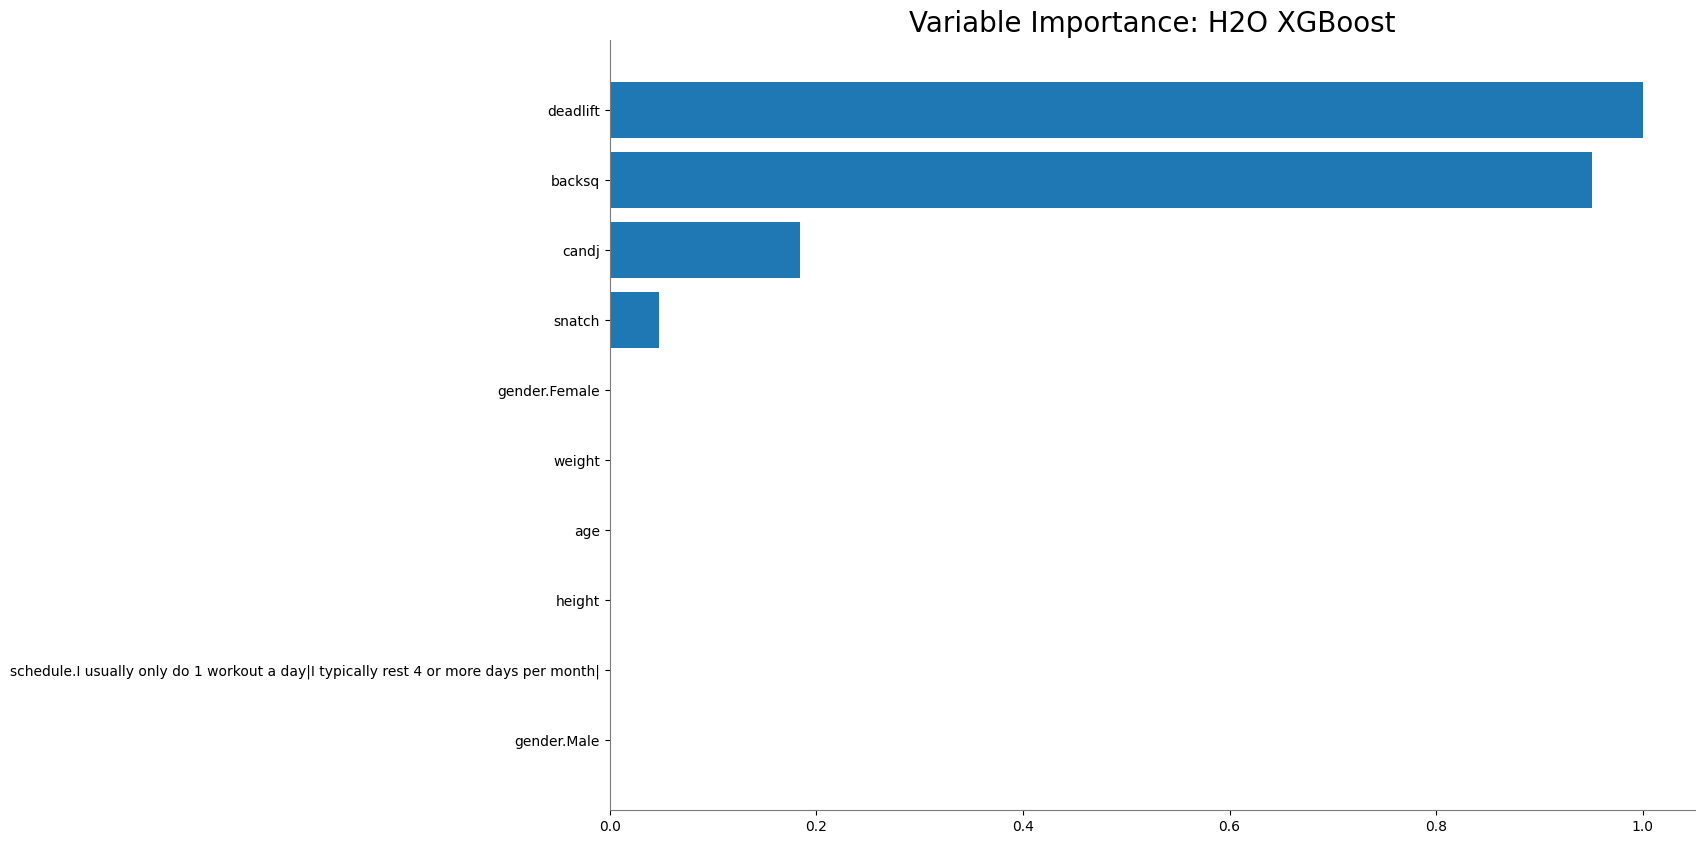

<Figure size 640x480 with 0 Axes>

In [35]:
out.varimp_plot()

In [36]:
aml.leader.download_mojo(path = "./")

'/content/GLM_1_AutoML_1_20251112_222959.zip'

Top 3 Features

In [58]:
top3_df = h2o_df[['deadlift', 'backsq', 'candj', 'total lift']]

top3_train,top3_test,top3_valid = top3_df.split_frame(ratios=[.7, .15])

In [59]:
y = "total lift"
x = top3_df.columns
x.remove(y)

In [60]:
aml = H2OAutoML(max_models = 10, seed = 10, exclude_algos = ["StackedEnsemble", "DeepLearning"], verbosity="info", nfolds=0)

In [61]:
aml.train(x = x, y = y, training_frame = top3_train, validation_frame=top3_valid)

AutoML progress: |
23:16:45.674: Project: AutoML_2_20251112_231645
23:16:45.674: Cross-validation disabled by user: no fold column nor nfolds > 1.
23:16:45.674: Setting stopping tolerance adaptively based on the training frame: 0.006880046322131817
23:16:45.674: Build control seed: 10
23:16:45.674: training frame: Frame key: AutoML_2_20251112_231645_training_py_77_sid_b359    cols: 4    rows: 21126  chunks: 3    size: 169824  checksum: -6081135460160344224
23:16:45.674: validation frame: Frame key: py_79_sid_b359    cols: 4    rows: 4492  chunks: 3    size: 36752  checksum: -6080811500004705490
23:16:45.675: leaderboard frame: Frame key: py_79_sid_b359    cols: 4    rows: 4492  chunks: 3    size: 36752  checksum: -6080811500004705490
23:16:45.675: blending frame: NULL
23:16:45.675: response column: total lift
23:16:45.675: fold column: null
23:16:45.675: weights column: null
23:16:45.675: Loading execution steps: [{XGBoost : [def_2 (1g, 10w), def_1 (2g, 10w), def_3 (3g, 10w), grid_1 (4

Model Details
=============
H2OGeneralizedLinearEstimator : Generalized Linear Modeling
Model Key: GLM_1_AutoML_2_20251112_231645


GLM Model: summary
    family    link      regularization              lambda_search                                                                number_of_predictors_total    number_of_active_predictors    number_of_iterations    training_frame
--  --------  --------  --------------------------  ---------------------------------------------------------------------------  ----------------------------  -----------------------------  ----------------------  ------------------------------------------------
    gaussian  identity  Ridge ( lambda = 0.02691 )  nlambda = 30, lambda.max = 26911.0, lambda.min = 0.02691, lambda.1se = -1.0  3                             3                              30                      AutoML_2_20251112_231645_training_py_77_sid_b359

ModelMetricsRegressionGLM: glm
** Reported on train data. **

MSE: 234.22264150401776
RMSE: 15.304334075810608
MAE: 11.268800572332887
RMSLE: 0.01656821719926599
Mean Residual Deviance: 234.22264150401776
R^2: 0.9969772935660778
Null degrees of freedom: 21125
Residual degrees of freedom: 21122
Null deviance: 1637005654.562724
Residual deviance: 4948187.524413879
AIC: 175232.19576333495

ModelMetricsRegressionGLM: glm
** Reported on validation data. **

MSE: 232.59386891456157
RMSE: 15.25102845432273
MAE: 11.134405250973815
RMSLE: 0.01668460108864051
Mean Residual Deviance: 232.59386891456157
R^2: 0.9969443718782737
Null degrees of freedom: 4491
Residual degrees of freedom: 4488
Null deviance: 341935716.1439011
Residual deviance: 1044811.6591642105
AIC: 37235.97189492899

Scoring History: 
     timestamp            duration    iteration    lambda    predictors    deviance_train      deviance_test       alpha    iterations    training_rmse       training_deviance    training_mae        training_r2         validation_rmse    validation_deviance    validation_mae      validation_r2
---  -------------------  ----------  -----------  --------  ------------  ------------------  ------------------  -------  ------------  ------------------  -------------------  ------------------  ------------------  -----------------  ---------------------  ------------------  ------------------
     2025-11-12 23:16:47  0.000 sec   1            .27E5     4             77471.66880435686   76105.26114978372   0.0
     2025-11-12 23:16:47  0.004 sec   2            .17E5     4             77461.87380033766   76095.63405742409   0.0
     2025-11-12 23:16:47  0.007 sec   3            .1E5      4             77446.10433943763   76080.13492824868   0.0
     2025-11-12 23:16:47  0.009 sec   4            .64E4     4             77420.7207014217    76055.18643881312   0.0
     2025-11-12 23:16:47  0.011 sec   5            .4E4      4             77379.876629323     76015.04251638429   0.0      5             15.304334075810608  234.22264150401776   11.268800572332887  0.9969772935660778  15.25102845432273  232.59386891456157     11.134405250973815  0.9969443718782737
     2025-11-12 23:16:47  0.015 sec   6            .25E4     4             77314.1774609331    75950.46965577544   0.0
     2025-11-12 23:16:47  0.017 sec   7            .15E4     4             77208.55588846948   75846.65878822726   0.0
     2025-11-12 23:16:47  0.020 sec   8            .96E3     4             77038.9332678534    75679.94414761098   0.0
     2025-11-12 23:16:47  0.022 sec   9            .6E3      4             76766.97277522988   75412.64631454775   0.0
     2025-11-12 23:16:47  0.026 sec   10           .37E3     4             76332.07277330475   74985.20306615466   0.0
---  ---                  ---         ---          ---       ---           ---                 ---                 ---      ---           ---                 ---                  ---                 ---                 ---                ---                    ---                 ---
     2025-11-12 23:16:47  0.053 sec   21  

In [62]:
lb = aml.leaderboard

In [63]:
lb.head()

model_id,rmse,mse,mae,rmsle,mean_residual_deviance
GLM_1_AutoML_2_20251112_231645,15.251,232.594,11.1344,0.0166846,232.594
GBM_2_AutoML_2_20251112_231645,16.5594,274.214,11.511,0.0219885,274.214
GBM_3_AutoML_2_20251112_231645,16.5974,275.475,11.4455,0.0283828,275.475
GBM_4_AutoML_2_20251112_231645,16.9356,286.816,11.5285,0.0175957,286.816
XRT_1_AutoML_2_20251112_231645,18.1726,330.242,12.0839,0.030398,330.242
DRF_1_AutoML_2_20251112_231645,18.2917,334.588,12.1229,0.0190587,334.588
XGBoost_1_AutoML_2_20251112_231645,18.6695,348.548,12.5796,0.0611498,348.548
GBM_1_AutoML_2_20251112_231645,18.9382,358.654,11.9502,0.0744056,358.654
XGBoost_2_AutoML_2_20251112_231645,18.9825,360.337,12.6987,0.0496492,360.337
XGBoost_3_AutoML_2_20251112_231645,20.5127,420.769,14.294,0.0469786,420.769


In [64]:
# Get models
model_ids = list(aml.leaderboard['model_id'].as_data_frame()['model_id'])
test_features = top3_test.drop(y)

print(f"\nTesting inference speed for {len(model_ids)} models...")

# Simple speed test
speed_results = []
for model_id in model_ids:
    try:
        model = h2o.get_model(model_id)

        # Warm up
        _ = model.predict(test_features.head(10))

        # Time prediction
        start_time = time.time()
        predictions = model.predict(test_features)
        end_time = time.time()

        total_time = end_time - start_time
        ms_per_sample = (total_time / test_features.nrows) * 1000

        speed_results.append({
            'model_id': model_id,
            'model_type': model_id.split('_')[0],
            'total_inference_seconds': total_time,
            'ms_per_sample': ms_per_sample,
            'samples_per_second': test_features.nrows / total_time
        })

        print(f"✅ {model_id}: {ms_per_sample:.2f} ms/sample")

    except Exception as e:
        print(f"❌ {model_id}: Failed - {str(e)}")
        continue

# Display results
if speed_results:
    df = pd.DataFrame(speed_results)

    print("\n" + "="*60)
    print("🏆 TOP 3 MODELS BY INFERENCE SPEED")
    print("="*60)

    fastest = df.nsmallest(3, 'ms_per_sample')
    for i, (_, row) in enumerate(fastest.iterrows(), 1):
        print(f"{i}. {row['model_id']}")
        print(f"   Speed: {row['ms_per_sample']:.2f} ms/sample")
        print(f"   Throughput: {row['samples_per_second']:.1f} samples/sec")
        print()

    print("\n📊 All Models Speed Ranking:")
    ranked_df = df.sort_values('ms_per_sample')
    print(ranked_df[['model_id', 'model_type', 'ms_per_sample', 'samples_per_second']].to_string(index=False))


Testing inference speed for 10 models...
glm prediction progress: |███████████████████████████████████████████████████████| (done) 100%
glm prediction progress: |███████████████████████████████████████████████████████| (done) 100%
✅ GLM_1_AutoML_2_20251112_231645: 0.00 ms/sample
gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%
gbm prediction progress: |

/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


███████████████████████████████████████████████████████| (done) 100%
✅ GBM_2_AutoML_2_20251112_231645: 0.05 ms/sample
gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%
gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%
✅ GBM_3_AutoML_2_20251112_231645: 0.05 ms/sample
gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%
gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%
✅ GBM_4_AutoML_2_20251112_231645: 0.05 ms/sample
drf prediction progress: |███████████████████████████████████████████████████████| (done) 100%
drf prediction progress: |███████████████████████████████████████████████████████| (done) 100%
✅ XRT_1_AutoML_2_20251112_231645: 0.05 ms/sample
drf prediction progress: |███████████████████████████████████████████████████████| (done) 100%
drf prediction progress: |████████████████████████████████████████████